In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("hotel_bookings_cleaned.csv")


In [3]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df['total_guests'] = df['adults'] + df['children'] + df['babies']

df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)

df['room_changed'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

is_canceled
0    72.476728
1    27.523272
Name: proportion, dtype: float64


C:\Users\HELAL\AppData\Local\Temp\ipykernel_17100\2180037331.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, palette='Set2')


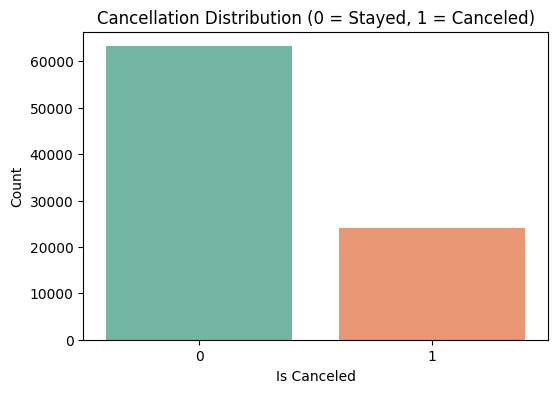

In [4]:
cancel_counts = df['is_canceled'].value_counts(normalize=True) * 100
print(cancel_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title('Cancellation Distribution (0 = Stayed, 1 = Canceled)')
plt.xlabel('Is Canceled')
plt.ylabel('Count')
plt.show()

###  Overall Cancellation Rate

 plot the split between bookings that were kept (Stayed) and bookings that were Canceled, using a simple `countplot` on the `is_canceled` column.

**Result:** 72.5% of bookings were honored, while 27.5% were canceled. Cancellation isn't a rare event here — roughly one in every four bookings gets canceled, which is significant enough to dig deeper into  

C:\Users\HELAL\AppData\Local\Temp\ipykernel_17100\1593292878.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hotel', data=df, palette='pastel')


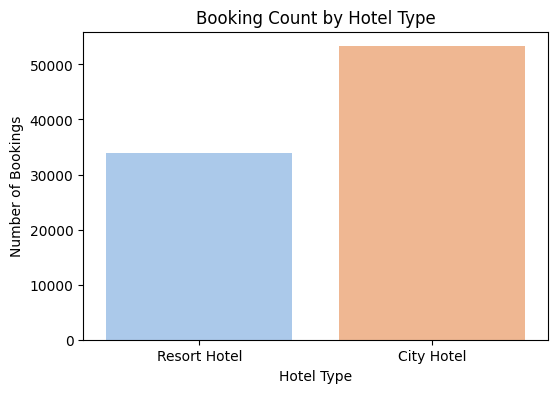

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='hotel', data=df, palette='pastel')
plt.title('Booking Count by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()

### Booking Distribution by Hotel Type

A `countplot` comparing the number of bookings between City Hotel and Resort Hotel.

**Result:** City Hotel accounts for a larger share of bookings (53,273 vs 33,955 for Resort Hotel), meaning city-based demand is the primary driver in this dataset, not resort stays.

C:\Users\HELAL\AppData\Local\Temp\ipykernel_17100\3848801257.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='Blues_r')


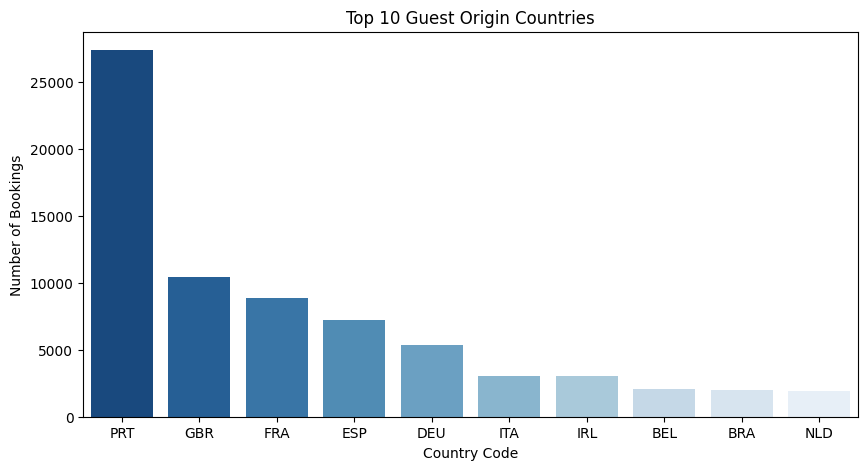

In [6]:
top_10_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='Blues_r')
plt.title('Top 10 Guest Origin Countries')
plt.xlabel('Country Code')
plt.ylabel('Number of Bookings')
plt.show()

### Top 10 Guest Origin Countries

used `value_counts().head(10)` on the `country` column to get the top ten countries guests are coming from, and plotted it with `barplot`.

**Result:** Portugal (PRT) dominates by a huge margin (27,354 bookings out of 87,228 total) — roughly a third of all guests come from a single country. This strongly suggests the hotel(s) are located in or near Portugal, with the UK, France and Spain forming a secondary tourist market rather than the core one.

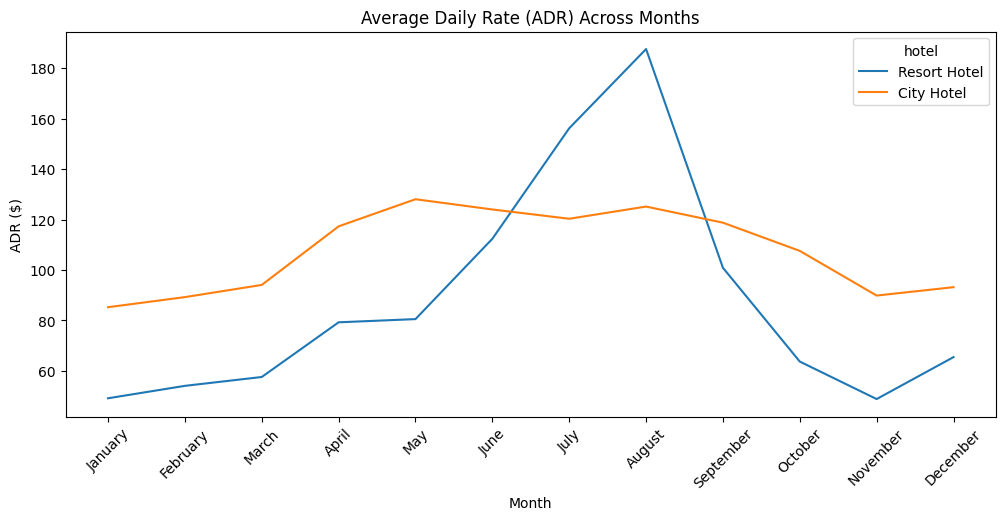

In [7]:

months_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December',
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'], categories=months_order, ordered=True
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    x='arrival_date_month', y='adr', hue='hotel', data=df, errorbar=None
)
plt.title('Average Daily Rate (ADR) Across Months')
plt.xlabel('Month')
plt.ylabel('ADR ($)')
plt.xticks(rotation=45)
plt.show()

### ADR Trend Across Months

A `lineplot` tracking the average daily rate (`adr`) month by month, split by hotel type (`hue='hotel'`) to compare both in the same chart.

**Result:** Price clearly follows a seasonal pattern, and the shape of that pattern differs between City Hotel and Resort Hotel — raising a follow-up question worth a dedicated analysis: do the two hotel types actually peak in different seasons? This matters if the data is ever used for dynamic pricing.

In [8]:
df.to_csv('hotel_bookings_final.csv', index=False)
print('Final dataset saved!')

Final dataset saved!
